# Testing new ART transmission and mortality

The goal is to allow for ART assignment to specify whether someone achieves EffectiveART or NonSuppressiveART, similar to ARTMortalityTable intervention from EMOD-HIV. 

I will implement, test, and demonstrate the following new model features

* New individual property which tracks ART Adherence - Effective vs NonSuppressive ART
* Allow Transmission to vary depending on Effective vs NonSuppressive ART
* Allow HIV-derived mortality to vary depending on Effective vs. NonSuppressive ART, as well as by age and sex

In [1]:
import starsim as ss
import stisim as sti
import matplotlib.pyplot as plt
import sciris as sc
import numpy as np
import pandas as pd

## Testing transmission

### Create a new class for testing mortality in each ART category

In [2]:
class ARTStatusTracker(ss.Analyzer):
    """
    Track deaths, living population, and onward transmissions, each broken
    out by ART-adherence category.

    Deaths need special handling: HIV.step_die() clears art_naive/on_art/
    on_effective_art/on_nonsuppressive_art/art_discontinued for agents who
    die (as it does for all disease states), so an agent's category can't be
    read off the live state after death. Instead, cache each agent's category
    at the end of every timestep, and when an agent dies (`ti_dead == ti`,
    which -- unlike the other states -- IS preserved through step_die), look
    up their most recently cached category rather than the (already-cleared)
    live state.

    Living population and transmission-source counts don't have this problem
    -- both only ever look at currently-alive, currently-infectious agents,
    so the live state is read directly, no caching needed.

    Requires `ss.infection_log()` to also be included in `analyzers=` for the
    transmission-attribution results to be populated (that's what actually
    turns on source/target tracking inside the HIV module).
    """
    CATEGORIES = ['art_naive', 'on_effective_art', 'on_nonsuppressive_art', 'art_discontinued']

    def __init__(self):
        super().__init__()
        self._cache = {}  # uid -> category, as of the end of the previous timestep

    def init_results(self):
        super().init_results()
        results = []
        for cat in self.CATEGORIES + ['on_art']:
            results += [
                ss.Result(f'deaths_{cat}', dtype=int, label=f'Deaths ({cat})'),
                ss.Result(f'n_alive_{cat}', dtype=int, label=f'Living with HIV ({cat})'),
                ss.Result(f'new_infections_from_{cat}', dtype=int, label=f'New infections from {cat}'),
            ]
        self.define_results(*results)

    def step(self):
        hiv = self.sim.diseases.hiv
        ti = self.ti

        # Deaths: attribute using each agent's cached (pre-death) category
        died_uids = (hiv.ti_dead == ti).uids
        for uid in died_uids:
            cat = self._cache.pop(int(uid), None)
            if cat is None:
                continue
            self.results[f'deaths_{cat}'][ti] += 1
            if cat in ('on_effective_art', 'on_nonsuppressive_art'):
                self.results['deaths_on_art'][ti] += 1

        # Onward transmissions this timestep, by source uid (requires ss.infection_log())
        log = hiv.infection_log
        new_source_uids = []
        if log is not None:
            for source, _target, t in log.edges(keys=True):
                if t == hiv.now and not pd.isna(source):
                    new_source_uids.append(int(source))
        src_uids = ss.uids(new_source_uids) if new_source_uids else ss.uids([])

        # Living population and transmission-source counts, by category
        for cat in self.CATEGORIES:
            alive_uids = (hiv.infected & hiv[cat]).uids
            n_alive = len(alive_uids)
            n_from_cat = int(hiv[cat][src_uids].sum()) if len(src_uids) else 0
            self.results[f'n_alive_{cat}'][ti] = n_alive
            self.results[f'new_infections_from_{cat}'][ti] = n_from_cat
            if cat in ('on_effective_art', 'on_nonsuppressive_art'):
                self.results['n_alive_on_art'][ti] += n_alive
                self.results['new_infections_from_on_art'][ti] += n_from_cat

        # Refresh the death-attribution cache for next timestep
        for cat in self.CATEGORIES:
            for uid in hiv[cat].uids:
                self._cache[int(uid)] = cat


def get_by_art_status(sim, metric):
    """
    Extract a result time series stratified by ART status.

    Args:
        sim: a run Sim with an ARTStatusTracker analyzer attached
        metric (str): result prefix -- one of 'deaths', 'n_alive', 'new_infections_from'

    Returns:
        dict mapping category name -> np.array (one value per timestep),
        for each of ARTStatusTracker.CATEGORIES plus the 'on_art' aggregate
    """
    tracker = sim.analyzers.artstatustracker
    groups = ARTStatusTracker.CATEGORIES + ['on_art']
    return {cat: tracker.results[f'{metric}_{cat}'].values for cat in groups}

### Run simulation

In [3]:
# Diagnose people first -- ART only initiates agents who are hiv.diagnosed.
hiv_test = sti.HIVTest(test_prob_data=0.3, start=2000)

# Absolute-count coverage target: ramps from 0 to 1000 people on ART between
# 2004 and 2005, then holds at 1000 for the rest of the sim. 50/50 split
# between effective (virally-suppressive) and non-suppressive ART.
art = sti.ART(
    coverage={'year': [2004, 2005], 'value': [0, 1000], 'format': 'n'},
    p_effective_art=0.5,
)
art_tracker = ARTStatusTracker()

sim = sti.Sim(
    diseases=sti.HIV(init_prev=ss.bernoulli(p=0.2)),
    n_agents=10_000, start=2000, stop=2020,
    interventions=[hiv_test, art],
    analyzers=[ss.infection_log(), art_tracker],
    rand_seed=2
)
sim.run(verbose=0)

Initializing sim with 10000 agents


Sim(n=10000; 2000—2020; networks=structuredsexual, maternalnet; diseases=hiv; interventions=hivtest, art; analyzers=infection_log, artstatustracker)

### Checking simulaiton results

In [4]:
hiv_res = sim.results.hiv
timevec = hiv_res.timevec
groups = ARTStatusTracker.CATEGORIES + ['on_art']

print(f"Final counts: on_effective_art={hiv_res.n_on_effective_art[-1]:.0f}, "
      f"on_nonsuppressive_art={hiv_res.n_on_nonsuppressive_art[-1]:.0f}")

Final counts: on_effective_art=517, on_nonsuppressive_art=471


#### Plot the numbers of people on effective vs. non-suppressive ART

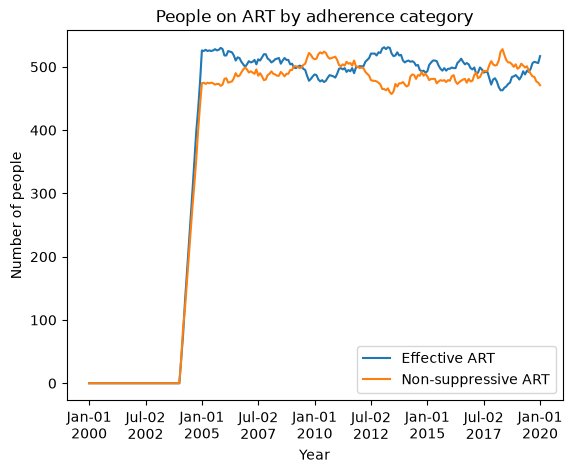

In [37]:
# Plot 1: number of people on effective vs. non-suppressive ART over time
fig1, ax1 = plt.subplots()
ax1.plot(timevec, hiv_res.n_on_effective_art, label='Effective ART')
ax1.plot(timevec, hiv_res.n_on_nonsuppressive_art, label='Non-suppressive ART')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of people')
ax1.set_title('People on ART by adherence category')
ax1.legend()

#### Plot number and rates of deaths by ART status

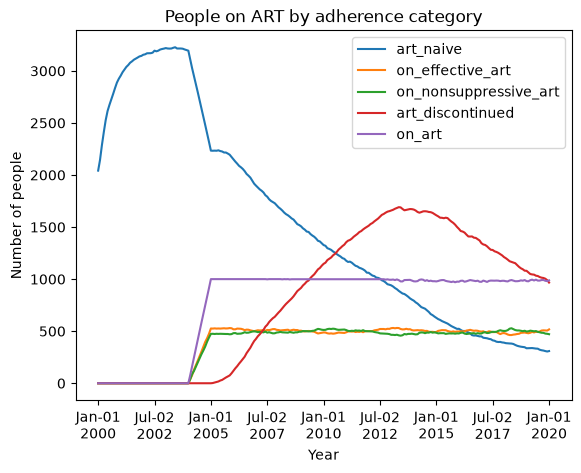

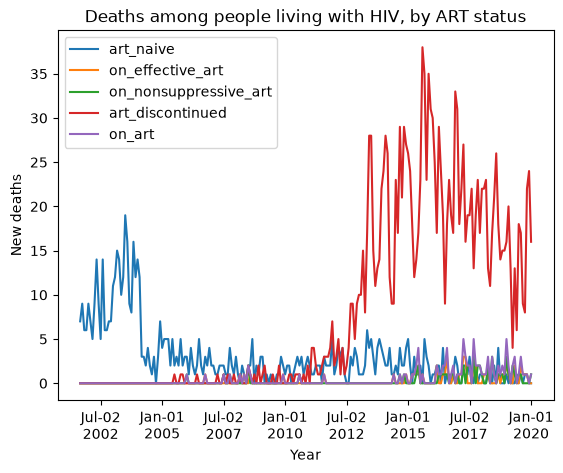

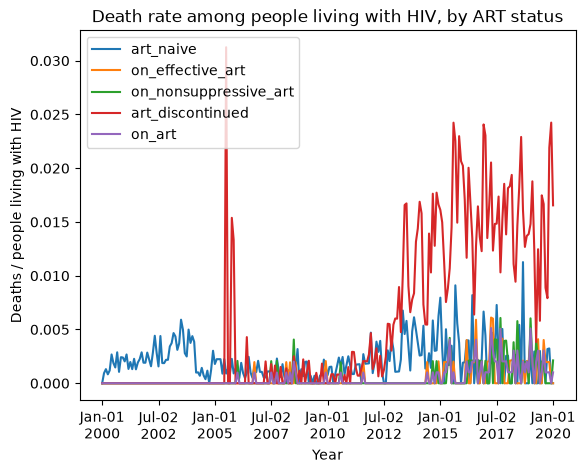

In [39]:
pops = get_by_art_status(sim, 'n_alive')
fig1, ax1 = plt.subplots()
for cat in groups:
    ax1.plot(timevec, pops[cat], label=cat)
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of people')
ax1.set_title('People on ART by adherence category')
ax1.legend()

# Plot 2: count of deaths among people living with HIV, by ART status
deaths = get_by_art_status(sim, 'deaths')
fig2, ax2 = plt.subplots()
for cat in groups:
    ax2.plot(timevec[20:], deaths[cat][20:], label=cat)
ax2.set_xlabel('Year')
ax2.set_ylabel('New deaths')
ax2.set_title('Deaths among people living with HIV, by ART status')
ax2.legend()

# Plot 3: death RATE (deaths / people living with HIV), by ART status
n_alive = get_by_art_status(sim, 'n_alive')
fig3, ax3 = plt.subplots()
for cat in groups:
    rate = np.divide(deaths[cat], n_alive[cat],
                      out=np.zeros_like(deaths[cat], dtype=float), where=(n_alive[cat] > 0))
    ax3.plot(timevec, rate, label=cat)
ax3.set_xlabel('Year')
ax3.set_ylabel('Deaths / people living with HIV')
ax3.set_title('Death rate among people living with HIV, by ART status')
ax3.legend()

#### Count numbers of onward transmissions

/var/folders/bd/msk_4j2n33xd2gh_w3_ts2sr0000gr/T/ipykernel_89638/3213775394.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


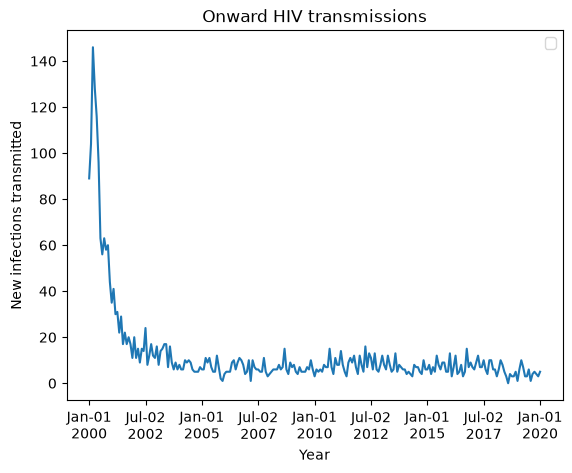

In [5]:
fig4, ax4 = plt.subplots()

ax4.plot(timevec, sim.results.hiv.new_infections)
ax4.set_xlabel('Year')
ax4.set_ylabel('New infections transmitted')
ax4.set_title('Onward HIV transmissions')
ax4.legend()

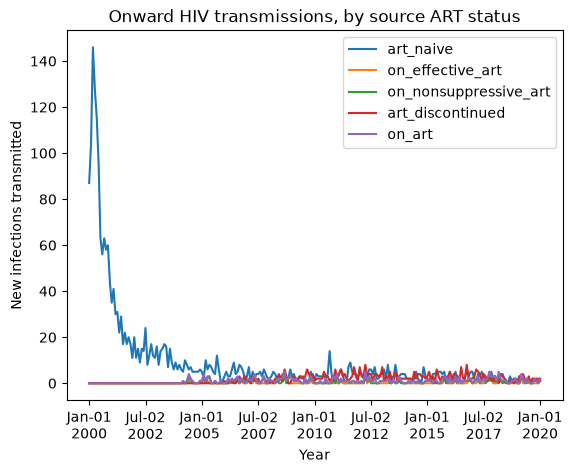

In [9]:
# Plot 4: onward transmissions, stratified by the SOURCE's ART status
new_infections = get_by_art_status(sim, 'new_infections_from')
fig4, ax4 = plt.subplots()
for cat in groups:
    ax4.plot(timevec, new_infections[cat], label=cat)
ax4.set_xlabel('Year')
ax4.set_ylabel('New infections transmitted')
ax4.set_title('Onward HIV transmissions, by source ART status')
ax4.legend()

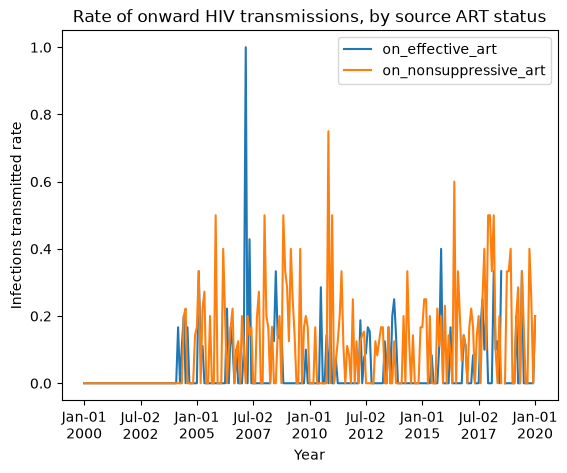

In [14]:
# Plot 5: onward transmissions, stratified by the SOURCE's ART status
new_infections = get_by_art_status(sim, 'new_infections_from')
n_alive = get_by_art_status(sim, 'n_alive')
fig5, ax5 = plt.subplots()
for cat in ['on_effective_art', 'on_nonsuppressive_art']:#groups:
    #ax5.plot(timevec, new_infections[cat]/n_alive[cat], label=cat)
    ax5.plot(timevec, new_infections[cat]/sim.results.hiv.new_infections, label=cat)
ax5.set_xlabel('Year')
ax5.set_ylabel('Infections transmitted rate')
ax5.set_title('Rate of onward HIV transmissions, by source ART status')
ax5.legend()

In [19]:
for cat in groups:
    print(cat, new_infections[cat].sum())

art_naive 2300.0
on_effective_art 71.0
on_nonsuppressive_art 158.0
art_discontinued 409.0
on_art 229.0


## Testing mortality

Demonstrate ART mortality by ART status, gender, age, and compare to older simpler version

### Define a new tracker for mortality by age and sex

In [33]:
def _bin_label(lo, hi, open_ended_at=200):
    return f'{lo}-{hi}' if hi < open_ended_at else f'{lo}+'


def _age_band(age, age_bins):
    for lo, hi in age_bins:
        if lo <= age < hi:
            return _bin_label(lo, hi)
    return None


class AgeSexAdherenceMortalityTracker(ss.Analyzer):
    """
    Tracks deaths and person-years, stratified by (user-specified) age
    bracket, sex, and treatment status: ART adherence category (effective
    vs. non-suppressive) for people on ART, plus a separate 'off_art'
    category (infected but not currently on ART, i.e. ART-naive or
    discontinued) for comparison.

    Deaths are attributed using each agent's (age bracket, sex, status) as
    of the END of the PREVIOUS timestep, cached across steps -- the same
    pattern ARTStatusTracker uses in art_transmission_test.py, and for the
    same reason: HIV.step_die() clears on_effective_art/on_nonsuppressive_art
    for agents who die this step, so the live state can't be read after
    the fact.
    """
    ADHERENCE = ['on_effective_art', 'on_nonsuppressive_art']  # on-ART categories only (used for old-vs-new comparisons)
    OFF_ART = 'off_art'  # infected & not on ART (art_naive or art_discontinued); mortality here is identical old vs. new

    def __init__(self, age_bins):
        super().__init__()
        self.age_bins = age_bins
        self.age_labels = [_bin_label(lo, hi) for lo, hi in age_bins]
        self._cache = {}  # uid -> (age_label, sex, status), as of end of previous timestep

    def init_results(self):
        super().init_results()
        results = []
        for age_label in self.age_labels:
            for sex in ('m', 'f'):
                for cat in self.ADHERENCE + [self.OFF_ART]:
                    key = f'{age_label}_{sex}_{cat}'
                    results += [
                        ss.Result(f'deaths_{key}', dtype=int),
                        ss.Result(f'person_years_{key}', dtype=float),
                    ]
        self.define_results(*results)

    def step(self):
        hiv = self.sim.diseases.hiv
        ti = self.ti
        ppl = self.sim.people
        dt_years = self.dt.years

        # Deaths this step, attributed via the pre-death cache
        died_uids = (hiv.ti_dead == ti).uids
        for uid in died_uids:
            cached = self._cache.pop(int(uid), None)
            if cached is None:
                continue
            label, sex, cat = cached
            self.results[f'deaths_{label}_{sex}_{cat}'][ti] += 1

        # Person-time this step, by CURRENT age band/sex/status
        cache = {}
        for cat, uids in [*((cat, hiv[cat].uids) for cat in self.ADHERENCE),
                           (self.OFF_ART, (hiv.infected & ~hiv.on_art).uids)]:
            for uid in uids:
                u = ss.uids([uid])
                label = _age_band(ppl.age[u][0], self.age_bins)
                if label is None:
                    continue
                sex = 'm' if bool(ppl.male[u][0]) else 'f'
                self.results[f'person_years_{label}_{sex}_{cat}'][ti] += dt_years
                cache[int(uid)] = (label, sex, cat)
        self._cache = cache



def summarize_mortality_comparison(trackers, yearvec, age_bins, date_range=None):
    """
    Build a tidy DataFrame of annual death rate (deaths / person-years), one
    row per (version, age band, sex, adherence category), aggregated only
    over timesteps whose calendar year falls in date_range.

    Args:
        date_range (tuple, optional): (start_year, end_year), inclusive of
            start_year and exclusive of end_year. Defaults to the full run.
    """
    if date_range is None:
        mask = np.ones(len(yearvec), dtype=bool)
    else:
        lo, hi = date_range
        mask = (yearvec >= lo) & (yearvec < hi)

    age_labels = [_bin_label(lo, hi) for lo, hi in age_bins]
    rows = []
    for version, tracker in trackers.items():
        for age_label in age_labels:
            for sex in ('m', 'f'):
                for cat in AgeSexAdherenceMortalityTracker.ADHERENCE:
                    key = f'{age_label}_{sex}_{cat}'
                    deaths = tracker.results[f'deaths_{key}'].values[mask].sum()
                    person_years = tracker.results[f'person_years_{key}'].values[mask].sum()
                    rate = deaths / person_years if person_years > 0 else np.nan
                    rows.append(dict(version=version, age_band=age_label, sex=sex, adherence=cat,
                                      deaths=deaths, person_years=person_years, annual_death_rate=rate))
    return pd.DataFrame(rows)


def plot_mortality_comparison(comparison, age_labels):
    """
    Grid of bar-chart panels: rows = sex, columns = ART adherence category.
    Each panel shows old vs. new annual on-ART death rate per age bracket.
    """
    adherence_cats = AgeSexAdherenceMortalityTracker.ADHERENCE
    fig, axes = plt.subplots(2, len(adherence_cats), figsize=(5.5 * len(adherence_cats), 7), sharey=True)
    x = np.arange(len(age_labels))
    width = 0.35
    for row, sex in enumerate(('m', 'f')):
        for col, cat in enumerate(adherence_cats):
            ax = axes[row, col]
            for offset, version, color in [(-1, 'old', 'tab:gray'), (1, 'new', 'tab:blue')]:
                rates = [
                    comparison.query('version == @version and sex == @sex and adherence == @cat and age_band == @label')['annual_death_rate'].iloc[0]
                    for label in age_labels
                ]
                ax.bar(x + offset * width / 2, rates, width, label=version, color=color)
            ax.set_xticks(x)
            ax.set_xticklabels(age_labels)
            ax.set_title(f'{cat}, sex={sex}')
            if col == 0:
                ax.set_ylabel('Annual death rate while on ART')
            ax.legend()
    fig.suptitle('Old (simple) vs. new (ARTMortalityTable) on-ART mortality, by age and sex')
    fig.tight_layout()
    return fig

def run_mortality_comparison(age_bins, n_agents=10_000, start=2000, stop=2020, coverage_target=0.6):
    """
    Run identical scenarios with the old (zero on-ART mortality) and new
    (ARTMortalityTable-style) behavior, and return each run's tracker plus
    the shared calendar-year time vector.
    """
    trackers = {}
    sim = None
    for version, use_table in [('old', False), ('new', True)]:
        hiv_test = sti.HIVTest(test_prob_data=0.3, start=start)
        ramp_end = min(start + 4, stop)
        art = sti.ART(coverage={'year': [start, ramp_end, stop], 'value': [0, coverage_target, coverage_target]}, p_effective_art=0.5)
        sim = sti.Sim(
            diseases=sti.HIV(init_prev=ss.bernoulli(p=0.2), use_art_mortality_table=use_table),
            n_agents=n_agents, start=start, stop=stop,
            interventions=[hiv_test, art],
            analyzers=[AgeSexAdherenceMortalityTracker(age_bins)],
        )
        sim.run(verbose=0)
        trackers[version] = sim.analyzers.agesexadherencemortalitytracker
    return trackers, sim.t.yearvec  # yearvec is identical for both runs (same start/stop/dt)

def yearly_mortality_by_adherence(trackers, yearvec, age_bins):
    """
    Total mortality per calendar year, pooled across all age brackets and
    both sexes, broken out into four categories: 'any' (on ART of any kind,
    i.e. effective + non-suppressive combined), 'effective', 'nonsuppressive',
    and 'off_art' (infected but not currently on ART). One row per
    (version, year, category).

    Note 'off_art' mortality is computed by the same code path regardless of
    `use_art_mortality_table`, so old vs. new should only differ there by
    simulation noise -- it's included for a full picture, not because the
    ARTMortalityTable toggle is expected to change it.
    """
    all_cats = AgeSexAdherenceMortalityTracker.ADHERENCE + [AgeSexAdherenceMortalityTracker.OFF_ART]
    age_labels = [_bin_label(lo, hi) for lo, hi in age_bins]
    years = np.floor(yearvec).astype(int)
    unique_years = sorted(set(years))

    rows = []
    for version, tracker in trackers.items():
        # Sum deaths/person-years across all age brackets and sexes, per timestep, per category
        deaths_by_cat = {cat: np.zeros(len(yearvec)) for cat in all_cats}
        py_by_cat = {cat: np.zeros(len(yearvec)) for cat in all_cats}
        for cat in all_cats:
            for age_label in age_labels:
                for sex in ('m', 'f'):
                    key = f'{age_label}_{sex}_{cat}'
                    deaths_by_cat[cat] += tracker.results[f'deaths_{key}'].values
                    py_by_cat[cat] += tracker.results[f'person_years_{key}'].values

        deaths_any = deaths_by_cat['on_effective_art'] + deaths_by_cat['on_nonsuppressive_art']
        py_any = py_by_cat['on_effective_art'] + py_by_cat['on_nonsuppressive_art']

        by_category = [
            ('any', deaths_any, py_any),
            ('effective', deaths_by_cat['on_effective_art'], py_by_cat['on_effective_art']),
            ('nonsuppressive', deaths_by_cat['on_nonsuppressive_art'], py_by_cat['on_nonsuppressive_art']),
            ('off_art', deaths_by_cat[AgeSexAdherenceMortalityTracker.OFF_ART], py_by_cat[AgeSexAdherenceMortalityTracker.OFF_ART]),
        ]
        for year in unique_years:
            mask = years == year
            for category, deaths_arr, py_arr in by_category:
                deaths = deaths_arr[mask].sum()
                person_years = py_arr[mask].sum()
                rate = deaths / person_years if person_years > 0 else np.nan
                rows.append(dict(version=version, year=year, category=category,
                                  deaths=deaths, person_years=person_years, annual_death_rate=rate))
    return pd.DataFrame(rows)


def plot_yearly_mortality(yearly):
    """ Total deaths per year, one panel per category, old vs. new overlaid. """
    categories = ['any', 'effective', 'nonsuppressive', 'off_art']
    fig, axes = plt.subplots(1, len(categories), figsize=(5 * len(categories), 4), sharey=True)
    for ax, category in zip(axes, categories):
        for version, color in [('old', 'tab:gray'), ('new', 'tab:blue')]:
            sub = yearly.query('version == @version and category == @category').sort_values('year')
            ax.plot(sub['year'], sub['deaths'], marker='o', label=version, color=color)
        ax.set_title(category)
        ax.set_xlabel('Year')
        ax.legend()
    axes[0].set_ylabel('Total deaths')
    fig.suptitle('Old vs. new: total deaths per year, by ART status')
    fig.tight_layout()
    return fig


In [34]:
start = 2005
stop = 2020
n_agents = 10_000
art_cov = 0.9

age_bins = [(0, 15), (15, 25), (25, 35), (35, 45), (45, 55), (55,65), (65,99)]
date_range = (start, stop)

trackers, yearvec = run_mortality_comparison(age_bins, n_agents=10_000, start=2000, stop=2020)

Initializing sim with 10000 agents
Initializing sim with 10000 agents


In [23]:
date_range_comparison = (2015,2020)
comparison = summarize_mortality_comparison(trackers, yearvec, age_bins, date_range=date_range_comparison)

print(f'Old vs. new ARTMortality comparison, {date_range_comparison[0]}-{date_range_comparison[1]} (annual death rate while on ART):')
print(comparison.pivot_table(index=['adherence', 'sex', 'age_band'], columns='version',
                              values='annual_death_rate').to_string(float_format='%.4f'))

Old vs. new ARTMortality comparison, 2015-2020 (annual death rate while on ART):
version                               new    old
adherence             sex age_band              
on_effective_art      f   15-25    0.0070 0.0000
                          25-35    0.0031 0.0000
                          35-45    0.0017 0.0000
                          45-55    0.0097 0.0000
                          55-65    0.0057 0.0000
                          65-99    0.0062 0.0000
                      m   15-25    0.0119 0.0000
                          25-35    0.0047 0.0000
                          35-45    0.0037 0.0000
                          45-55    0.0130 0.0000
                          55-65    0.0018 0.0000
                          65-99    0.0045 0.0000
on_nonsuppressive_art f   15-25    0.0123 0.0000
                          25-35    0.0101 0.0000
                          35-45    0.0109 0.0000
                          45-55    0.0084 0.0015
                          55-65    0.

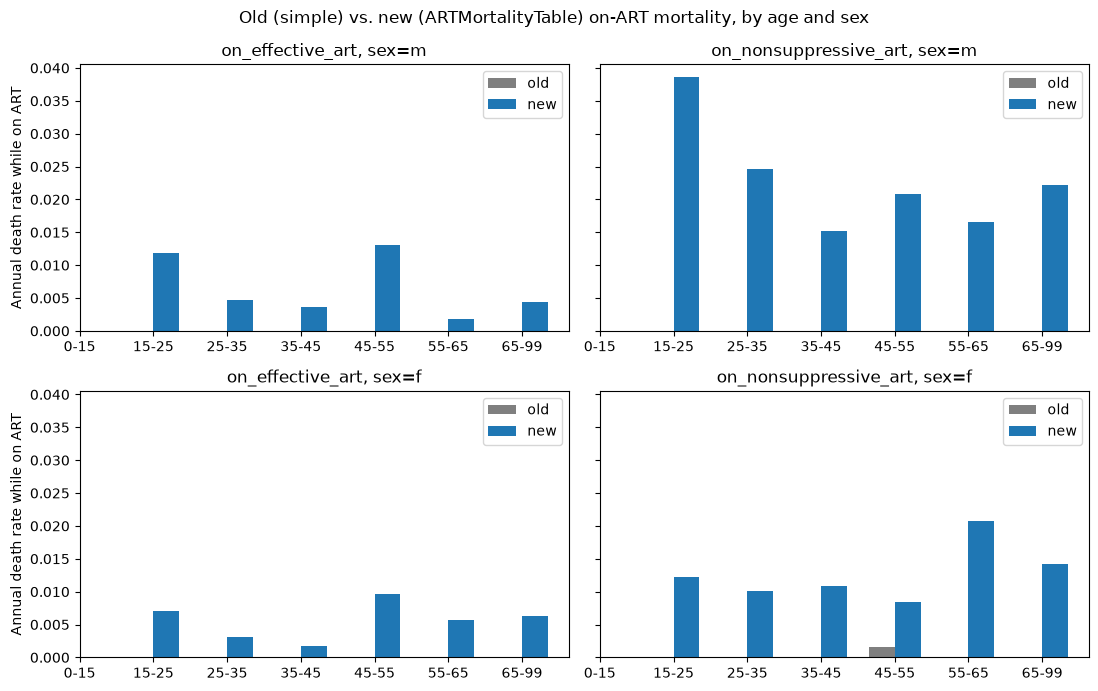

In [24]:
age_labels = [_bin_label(lo, hi) for lo, hi in age_bins]
plot_mortality_comparison(comparison, age_labels)

plt.show()

### Total mortality by adherence 


Total on-ART deaths per year, by adherence category:
category any     effective     nonsuppressive     off_art    
version  new old       new old            new old     new old
year                                                         
2000       4   0         0   0              4   0      53  53
2001       5   0         0   0              5   0      63  62
2002       9   1         4   1              5   0      58  58
2003      18   0         5   0             13   0      40  40
2004      21   0         6   0             15   0      42  42
2005      20   0         6   0             14   0      30  30
2006      19   0         7   0             12   0      19  21
2007      26   2         7   1             19   1      17  17
2008      15   0         3   0             12   0      22  25
2009      26   0         7   0             19   0      26  27
2010      28   1         7   0             21   1      15  16
2011      24   0         6   0             18   0      24  25
2012      24   0

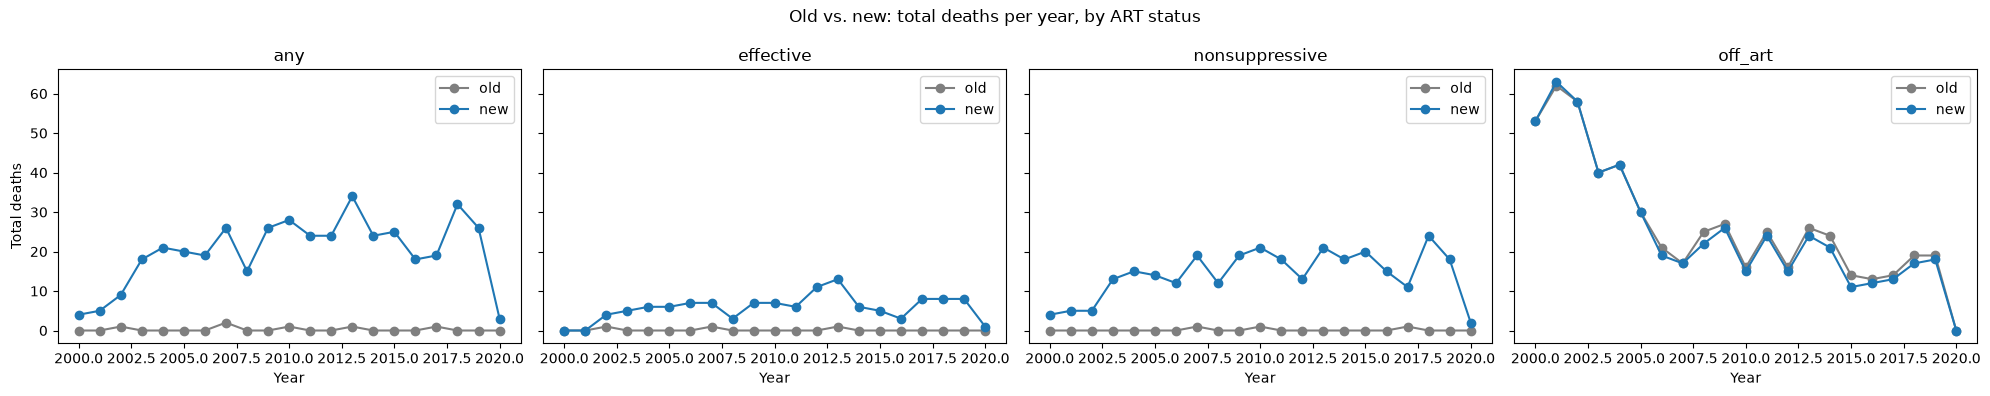

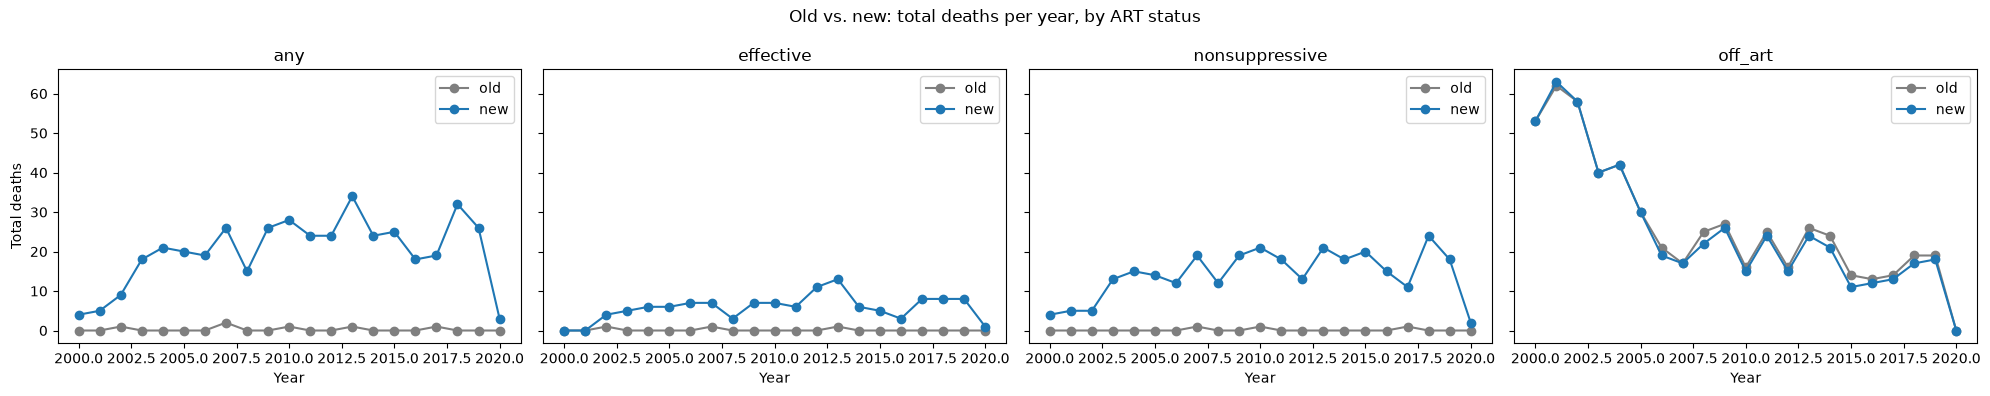

In [35]:
yearly = yearly_mortality_by_adherence(trackers, yearvec, age_bins)
print()
print('Total on-ART deaths per year, by adherence category:')
print(yearly.pivot_table(index='year', columns=['category', 'version'], values='deaths').to_string(float_format='%.0f'))
plot_yearly_mortality(yearly)

### Testing duration spent on ART

In [38]:
class ARTDurationTracker(ss.Analyzer):
    """
    Record start/stop calendar-years (and age at start) for every ART
    "spell" -- a contiguous period an agent spends on_art (effective or
    non-suppressive), ending in voluntary/program discontinuation, death, or
    (if ongoing at sim end) right-censoring.
    """
    def __init__(self, age_bins):
        super().__init__()
        self.age_bins = age_bins
        self._active = {}  # uid -> (spell start year, age at spell start)
        self.spells = []    # list of dicts: uid, start, stop, duration, end_reason, age_at_start, age_band

    def step(self):
        hiv = self.sim.diseases.hiv
        now = self.now.years  # numeric calendar year, e.g. 2013.5
        on_art_now = set(int(u) for u in hiv.on_art.uids)

        # New spells: agents who (re-)started ART this step
        starting = (hiv.ti_art == self.ti) & hiv.on_art
        ages = self.sim.people.age
        for uid in starting.uids:
            if int(uid) not in self._active:
                age_at_start = float(ages[ss.uids([uid])][0])
                self._active[int(uid)] = (now, age_at_start)

        # Ended spells: previously-tracked agents no longer on ART. Covers
        # both stop_art() discontinuation and death (HIV.step_die clears
        # on_art for agents who die, whatever the cause of death).
        ended_uids = [uid for uid in self._active if uid not in on_art_now]
        alive = self.sim.people.alive
        for uid in ended_uids:
            start, age_at_start = self._active.pop(uid)
            is_alive = bool(alive[ss.uids([uid])][0])
            reason = 'stopped' if is_alive else 'death'
            self.spells.append(dict(
                uid=uid, start=start, stop=now, duration=now - start, censored=False,
                end_reason=reason, age_at_start=age_at_start, age_band=_age_band(age_at_start, self.age_bins),
            ))


def kaplan_meier(durations, censored):
    """
    Manual Kaplan-Meier estimator of the survival function (fraction of
    spells still ongoing) as a function of time since ART initiation.

    Args:
        durations (array-like): observed spell length for each spell
            (time-to-event for completed spells, time-to-censoring for
            ongoing ones)
        censored (array-like of bool): True if the spell was still ongoing
            at the end of the observation window (right-censored)

    Returns:
        (times, survival): step-function coordinates suitable for plotting
    """
    df = pd.DataFrame({'t': durations, 'censored': censored}).sort_values('t')
    times, surv = [0.0], [1.0]
    survival = 1.0
    remaining = df
    for t in sorted(df['t'].unique()):
        n_at_risk = len(remaining)
        if n_at_risk == 0:
            break
        n_events = ((remaining['t'] == t) & (~remaining['censored'])).sum()
        survival *= (1 - n_events / n_at_risk)
        times.append(t)
        surv.append(survival)
        remaining = remaining[remaining['t'] > t]
    return np.array(times), np.array(surv)


def run_duration_test(age_bins, n_agents=10_000, start=2000, stop=2040, coverage_target=0.6):
    """
    Run a sim with a ramping-then-held ART coverage target and return a
    DataFrame of every observed ART spell (completed or censored), tagged
    with the agent's age band at spell start.
    """
    hiv_test = sti.HIVTest(test_prob_data=0.3, start=start)
    # Ramping coverage target with a long hold, similar to real usage
    # (hivsim_examples/zimbabwe/sim.py) -- this activates ART's
    # coverage-correction logic, so realized spell lengths reflect BOTH the
    # random dur_on_art draw AND program-capacity-driven early stops.
    ramp_end = min(start + 10, stop)
    art = sti.ART(coverage={'year': [start, ramp_end, stop], 'value': [0, coverage_target, coverage_target]})

    sim = sti.Sim(
        diseases=sti.HIV(init_prev=ss.bernoulli(p=0.2)),
        n_agents=n_agents, start=start, stop=stop,
        interventions=[hiv_test, art],
        analyzers=[ARTDurationTracker(age_bins)],
    )
    sim.run(verbose=0)

    # NB: Sim deep-copies analyzers on init, so the tracker actually
    # populated during the run is `sim.analyzers.artdurationtracker`, not
    # the object constructed above.
    tracker = sim.analyzers.artdurationtracker

    # Anyone still on ART at sim end is a right-censored spell
    final_year = sim.t.yearvec[-1]
    censored_spells = [
        dict(uid=uid, start=s, stop=final_year, duration=final_year - s, censored=True,
             end_reason='ongoing', age_at_start=a, age_band=_age_band(a, age_bins))
        for uid, (s, a) in tracker._active.items()
    ]
    return pd.DataFrame(tracker.spells + censored_spells)


class AgeDependentARTDropout(ss.Intervention):
    """
    Standalone custom intervention: overrides HIV.ti_stop_art for
    newly-initiated ART agents with an age-dependent EXPONENTIAL retention
    duration -- i.e. a constant annual dropout HAZARD per age band -- instead
    of HIV's built-in single lognormal `dur_on_art`, which has no age
    dependence at all (see art_implementation_notes.md section 8, "Option
    A/B", for why exponential is the distribution that exactly reproduces a
    flat annual dropout rate: it's the constant-hazard distribution).

    Must be placed AFTER `ART` in `interventions=[...]`: it runs later in
    the same timestep, after ART.step()/HIV.start_art() has already set
    ti_art/ti_stop_art for anyone starting ART this step, and simply
    overwrites ti_stop_art for those same agents with an age-conditioned
    draw. This doesn't disturb ART's handling of agents *stopping* ART this
    step, since that check (against durations set on a prior timestep)
    already happened earlier in the same ART.step() call.

    Agents outside every band in `age_dropout` (e.g. under-15 agents
    diagnosed at sim initialization, bypassing the usual age-restricted
    HIVTest eligibility) are left with whatever ti_stop_art HIV's own
    start_art() already set -- i.e. they silently fall back to the
    unmodified lognormal dur_on_art.

    Args:
        age_dropout: list of (age_lo, age_hi, mean_years) tuples. mean_years
            is the mean retention duration under a constant-hazard
            (exponential) dropout model, i.e. mean_years = 1 / annual_dropout_rate.
            Example: [(15, 25, 20/3), (25, 200, 20)] reproduces a 15%/yr
            dropout hazard under 25 and a 5%/yr dropout hazard 25+.
    """
    def __init__(self, age_dropout, **kwargs):
        super().__init__()
        self.age_dropout = age_dropout
        self.define_pars(**{
            f'dur_{i}': ss.expon(scale=ss.years(mean_years))
            for i, (_, _, mean_years) in enumerate(age_dropout)
        })
        self.update_pars(**kwargs)

    def step(self):
        hiv = self.sim.diseases.hiv
        ti = self.ti
        just_started = ((hiv.ti_art == ti) & hiv.on_art).uids
        if len(just_started) == 0:
            return
        ages = self.sim.people.age[just_started]
        for i, (lo, hi, _) in enumerate(self.age_dropout):
            in_band = just_started[(ages >= lo) & (ages < hi)]
            if len(in_band) == 0:
                continue
            dur = self.pars[f'dur_{i}'].rvs(in_band)
            hiv.ti_stop_art[in_band] = ti + dur.astype(int)


def run_duration_test_age_dropout(age_dropout, min_age=15, n_agents=10_000, start=2000, stop=2040, coverage_target=0.6):
    """
    Run a sim where ART is restricted to agents aged >= min_age, and
    retention duration is drawn from an age-dependent exponential dropout
    hazard (AgeDependentARTDropout) instead of HIV's built-in single
    lognormal dur_on_art. Returns a spells DataFrame in the same shape as
    run_duration_test(), tagged by age band at initiation using the SAME
    age bands as `age_dropout`, so the resulting plots line up with the
    hazard groups actually used.
    """
    age_bins = [(lo, hi) for lo, hi, _ in age_dropout]

    hiv_test = sti.HIVTest(
        test_prob_data=0.3, start=start,
        eligibility=lambda sim: ~sim.diseases.hiv.diagnosed & (sim.people.age >= min_age),
    )
    ramp_end = min(start + 10, stop)
    art = sti.ART(coverage={'year': [start, ramp_end, stop], 'value': [0, coverage_target, coverage_target]})
    dropout = AgeDependentARTDropout(age_dropout)

    sim = sti.Sim(
        diseases=sti.HIV(init_prev=ss.bernoulli(p=0.2)),
        n_agents=n_agents, start=start, stop=stop,
        interventions=[hiv_test, art, dropout],  # dropout must come AFTER art
        analyzers=[ARTDurationTracker(age_bins)],
    )
    sim.run(verbose=0)
    tracker = sim.analyzers.artdurationtracker

    final_year = sim.t.yearvec[-1]
    censored_spells = [
        dict(uid=uid, start=s, stop=final_year, duration=final_year - s, censored=True,
             end_reason='ongoing', age_at_start=a, age_band=_age_band(a, age_bins))
        for uid, (s, a) in tracker._active.items()
    ]
    return pd.DataFrame(tracker.spells + censored_spells)


def print_duration_summary(df, age_labels):
    """ Print n spells, completed-spell mean/median, and KM restricted mean, overall and per age band. """
    for label in list(age_labels) + ['overall']:
        sub = df if label == 'overall' else df[df['age_band'] == label]
        if len(sub) == 0:
            print(f'{label}: no spells observed')
            continue
        completed = sub[~sub['censored']]
        times, surv = kaplan_meier(sub['duration'].values, sub['censored'].values)
        rmst = np.sum(np.diff(times) * (surv[:-1] + surv[1:]) / 2)
        mean_c = completed['duration'].mean() if len(completed) else np.nan
        median_c = completed['duration'].median() if len(completed) else np.nan
        print(f'{label}: n={len(sub)} ({len(completed)} completed, {len(sub) - len(completed)} censored), '
              f'completed mean/median={mean_c:.2f}/{median_c:.2f} yr, '
              f'KM restricted mean (lower bound)={rmst:.2f} yr')


def plot_duration_histograms(df, age_labels):
    """ Grid of histograms of completed-spell durations, one panel per age bracket. """
    completed = df[~df['censored']]
    fig, axes = plt.subplots(1, len(age_labels), figsize=(4 * len(age_labels), 4), sharey=True)
    if len(age_labels) == 1:
        axes = [axes]
    for ax, label in zip(axes, age_labels):
        sub = completed[completed['age_band'] == label]
        ax.hist(sub['duration'], bins=20)
        ax.set_title(label)
        ax.set_xlabel('Time on ART (years)')
    axes[0].set_ylabel('Number of completed spells')
    fig.suptitle('Distribution of completed ART-spell durations, by age at initiation')
    fig.tight_layout()
    return fig


def plot_km_by_age(df, age_labels):
    """ Overlaid Kaplan-Meier retention curves, one line per age bracket plus an overall line. """
    fig, ax = plt.subplots()
    for label in age_labels:
        sub = df[df['age_band'] == label]
        if len(sub) == 0:
            continue
        times, surv = kaplan_meier(sub['duration'].values, sub['censored'].values)
        ax.step(times, surv, where='post', label=label)
    times, surv = kaplan_meier(df['duration'].values, df['censored'].values)
    ax.step(times, surv, where='post', label='overall', color='k', linestyle='--')
    ax.set_xlabel('Years since ART initiation')
    ax.set_ylabel('Fraction still on ART')
    ax.set_title('Kaplan-Meier ART retention curve, by age at initiation')
    ax.set_ylim(0, 1.05)
    ax.legend()
    return fig

Initializing sim with 10000 agents
=== Check 1: baseline (HIV.dur_on_art, no age dependence) ===
0-15: n=429 (417 completed, 12 censored), completed mean/median=3.35/2.67 yr, KM restricted mean (lower bound)=4.24 yr
15-25: n=1347 (1306 completed, 41 censored), completed mean/median=3.23/2.75 yr, KM restricted mean (lower bound)=4.25 yr
25-35: n=3475 (3408 completed, 67 censored), completed mean/median=3.21/2.67 yr, KM restricted mean (lower bound)=3.82 yr
35-45: n=5137 (4834 completed, 303 censored), completed mean/median=3.01/2.58 yr, KM restricted mean (lower bound)=3.42 yr
45-55: n=5312 (4831 completed, 481 censored), completed mean/median=2.97/2.58 yr, KM restricted mean (lower bound)=3.29 yr
55-65: n=4653 (4197 completed, 456 censored), completed mean/median=2.91/2.58 yr, KM restricted mean (lower bound)=3.22 yr
65-100: n=5890 (4769 completed, 1121 censored), completed mean/median=2.83/2.58 yr, KM restricted mean (lower bound)=3.00 yr
overall: n=26243 (23762 completed, 2481 censor

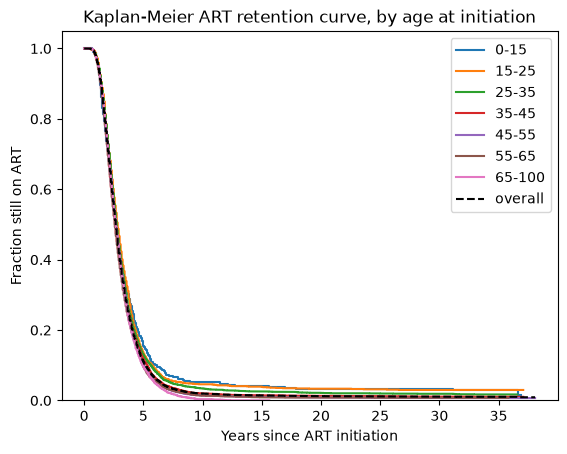

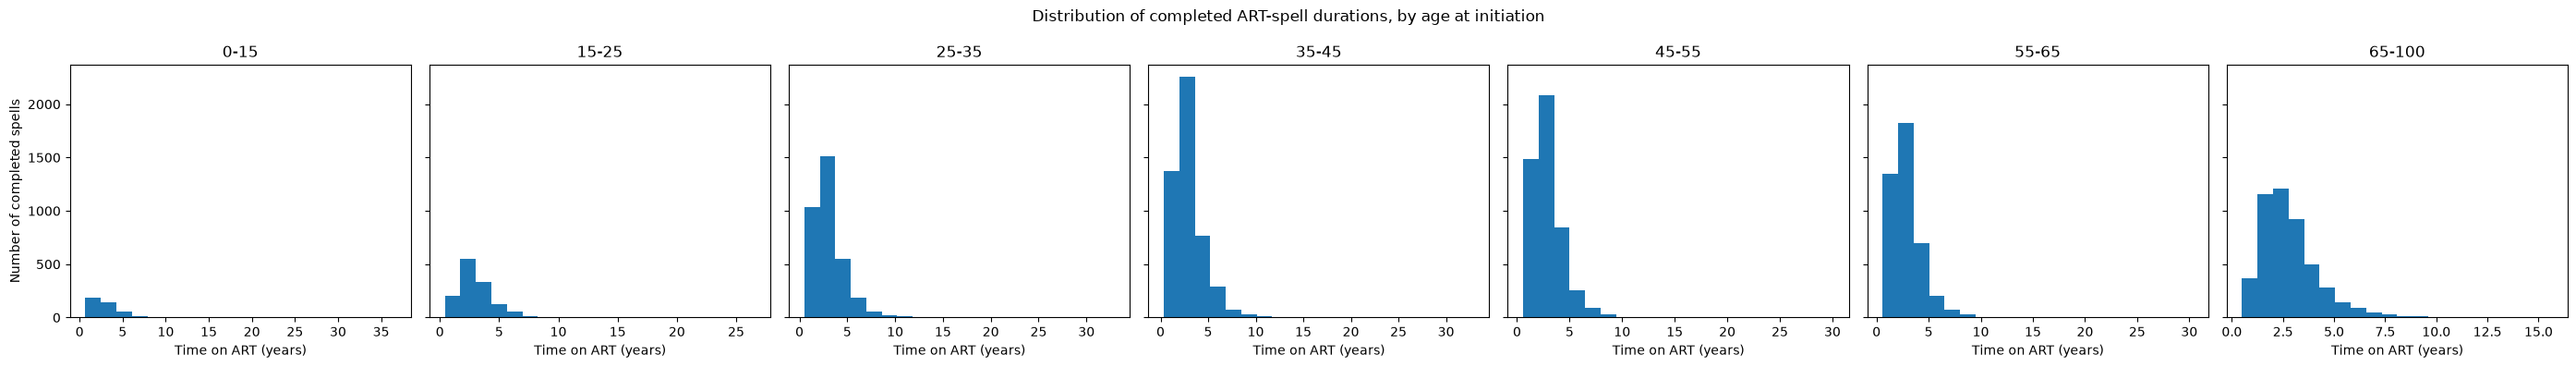

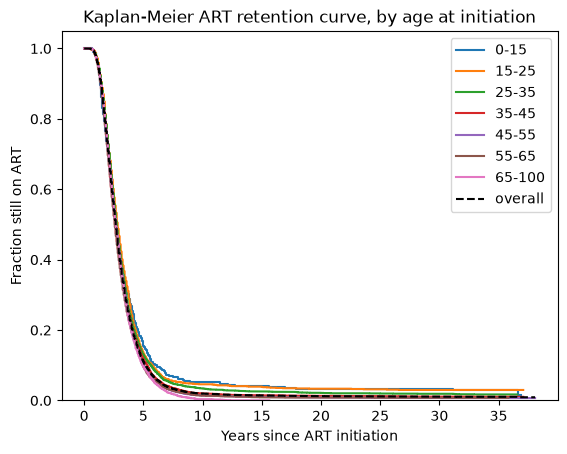

In [39]:
age_bins = [(0, 15), (15, 25), (25, 35), (35, 45), (45, 55), (55, 65), (65, 100)]
age_labels = [_bin_label(lo, hi) for lo, hi in age_bins]

df = run_duration_test(age_bins, n_agents=10_000, start=2000, stop=2040)

print('=== Check 1: baseline (HIV.dur_on_art, no age dependence) ===')
print_duration_summary(df, age_labels)
plot_duration_histograms(df, age_labels)
plot_km_by_age(df, age_labels)

Initializing sim with 10000 agents

=== Check 2: age-dependent exponential dropout hazard (AgeDependentARTDropout) ===
15-25: n=624 (616 completed, 8 censored), completed mean/median=6.24/4.42 yr, KM restricted mean (lower bound)=6.54 yr
25+: n=2726 (2305 completed, 421 censored), completed mean/median=12.03/10.25 yr, KM restricted mean (lower bound)=15.76 yr
overall: n=3350 (2921 completed, 429 censored), completed mean/median=10.81/8.67 yr, KM restricted mean (lower bound)=14.04 yr


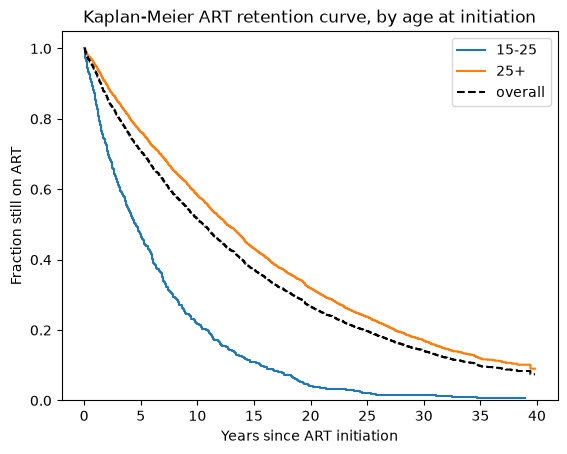

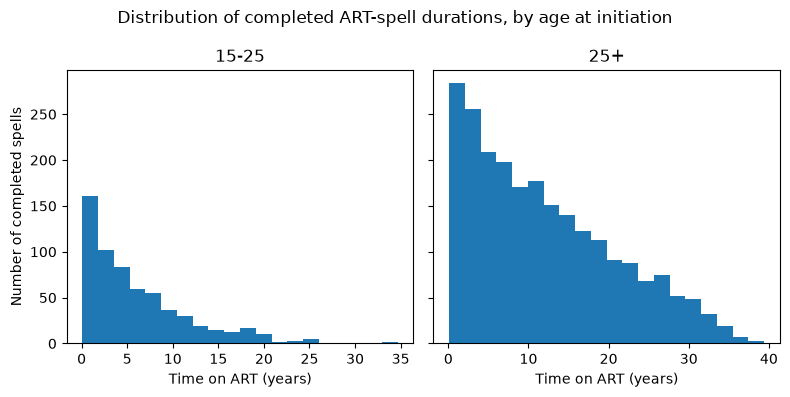

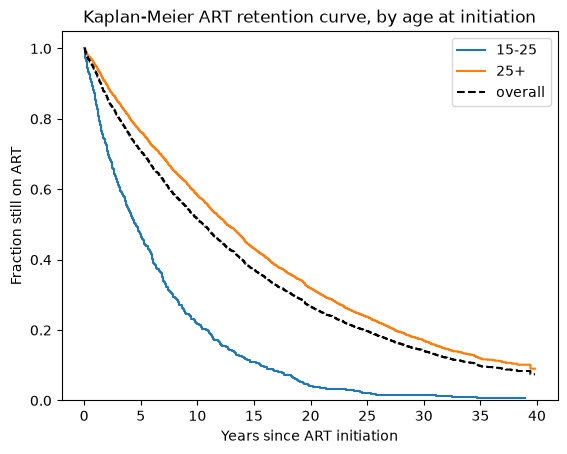

In [40]:
age_dropout = [(15, 25, 20 / 3), (25, 200, 20)]  # (age_lo, age_hi, mean retention years = 1/annual_dropout_rate)
age_dropout_labels = [_bin_label(lo, hi) for lo, hi, _ in age_dropout]

df_custom = run_duration_test_age_dropout(age_dropout, min_age=15, n_agents=10_000, start=2000, stop=2040)

print()
print('=== Check 2: age-dependent exponential dropout hazard (AgeDependentARTDropout) ===')
print_duration_summary(df_custom, age_dropout_labels)
plot_duration_histograms(df_custom, age_dropout_labels)
plot_km_by_age(df_custom, age_dropout_labels)